# Football Prediction Model

Creating a model to predict football outcomes, such as correct scores, match results (win, lose, or draw), and head-to-head outcomes using data from **Football-Data.co.ke** or similar sources requires several steps. Here's a detailed guide:

### 1. **Data Collection and Preprocessing**
First, gather the required data from **Football-Data.co.ke**. You need match data including:
- Team names
- Dates of matches
- Match outcomes (home win, away win, draw)
- Goals scored by each team (correct score)
- Head-to-head match results

This data can often be found in downloadable CSV files on the site. You can then load it into Python using `Pandas`.

### Import necessary libraries

In [27]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


## Merge the excell files

In [ ]:

# get list of excell files
folder_path = '/home/sirian/Documents/football/data'
files = [f for f in os.listdir(folder_path) if f.endswith('.xls') or f.endswith('.xlsx') ]

# load data to dataframes
dataframes = []
for file in files:
    df = pd.read_excel(os.path.join(folder_path, file))
    dataframes.append(df)
    
# merge dataframes    
merged_df = pd.concat(dataframes, ignore_index=True)

#export dataframe to csv
output_path = '/home/sirian/Documents/football/data'
merged_df.to_csv(os.path.join(output_path, 'merged_data.csv'), index=False)

print('Data merged and saved as merged_data.csv')

In [28]:
columns = data.columns
columns

Index(['Country', 'League', 'Season', 'Date', 'Time', 'Home', 'Away', 'HG',
       'AG', 'Res', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH',
       'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA'],
      dtype='object')

column names explained
HG - Home Goals
AG - Away goals
Res - Result
PSCH - 

## Notes for Football Data

All data is in csv format, ready for use within standard spreadsheet applications. Please note that some abbreviations are no longer in use (in particular odds from specific bookmakers no longer used) and refer to data collected in earlier seasons. For a current list of what bookmakers are included in the dataset please visit http://www.football-data.co.uk/matches.php

Key to results data:

- Div = League Division
- Date = Match Date (dd/mm/yy)
- Time = Time of match kick off
- HomeTeam = Home Team
- AwayTeam = Away Team
- FTHG and HG = Full Time Home Team Goals
- FTAG and AG = Full Time Away Team Goals
- FTR and Res = Full Time Result (H=Home Win, D=Draw, A=Away Win)
- HTHG = Half Time Home Team Goals
- HTAG = Half Time Away Team Goals
- HTR = Half Time Result (H=Home Win, D=Draw, A=Away Win)

- Match Statistics (where available)
- Attendance = Crowd Attendance
- Referee = Match Referee
- HS = Home Team Shots
- AS = Away Team Shots
- HST = Home Team Shots on Target
- AST = Away Team Shots on Target
- HHW = Home Team Hit Woodwork
- AHW = Away Team Hit Woodwork
- HC = Home Team Corners
- AC = Away Team Corners
- HF = Home Team Fouls Committed
- AF = Away Team Fouls Committed
- HFKC = Home Team Free Kicks Conceded
- AFKC = Away Team Free Kicks Conceded
- HO = Home Team Offsides
- AO = Away Team Offsides
- HY = Home Team Yellow Cards
- AY = Away Team Yellow Cards
- HR = Home Team Red Cards
- AR = Away Team Red Cards
- HBP = Home Team Bookings Points (10 = yellow, 25 = red)
- ABP = Away Team Bookings Points (10 = yellow, 25 = red)

Note that Free Kicks Conceeded includes fouls, offsides and any other offense commmitted and will always be equal to or higher than the number of fouls. Fouls make up the vast majority of Free Kicks Conceded. Free Kicks Conceded are shown when specific data on Fouls are not available (France 2nd, Belgium 1st and Greece 1st divisions).

Note also that English and Scottish yellow cards do not include the initial yellow card when a second is shown to a player converting it into a red, but this is included as a yellow (plus red) for European games.


[Pre-closing odds. For closing odds, see further below.]

Key to 1X2 (match) betting odds data: 

- B365H = Bet365 home win odds
- B365D = Bet365 draw odds
- B365A = Bet365 away win odds
- BFH = Betfair home win odds
- BFD = Betfair draw odds
- BFA = Betfair away win odds
- BSH = Blue Square home win odds
- BSD = Blue Square draw odds
- BSA = Blue Square away win odds
- BWH = Bet&Win home win odds
- BWD = Bet&Win draw odds
- BWA = Bet&Win away win odds
- GBH = Gamebookers home win odds
- GBD = Gamebookers draw odds
- GBA = Gamebookers away win odds
- IWH = Interwetten home win odds
- IWD = Interwetten draw odds
- IWA = Interwetten away win odds
- LBH = Ladbrokes home win odds
- LBD = Ladbrokes draw odds
- LBA = Ladbrokes away win odds
- PSH and PH = Pinnacle home win odds
- PSD and PD = Pinnacle draw odds
- PSA and PA = Pinnacle away win odds
- SOH = Sporting Odds home win odds
- SOD = Sporting Odds draw odds
- SOA = Sporting Odds away win odds
- SBH = Sportingbet home win odds
- SBD = Sportingbet draw odds
- SBA = Sportingbet away win odds
- SJH = Stan James home win odds
- SJD = Stan James draw odds
- SJA = Stan James away win odds
- SYH = Stanleybet home win odds
- SYD = Stanleybet draw odds
- SYA = Stanleybet away win odds
- VCH = VC Bet home win odds
- VCD = VC Bet draw odds
- VCA = VC Bet away win odds
- WHH = William Hill home win odds
- WHD = William Hill draw odds
- WHA = William Hill away win odds

### Bb1X2 = Number of BetBrain bookmakers used to calculate match odds averages and maximums
- BbMxH = Betbrain maximum home win odds
- BbAvH = Betbrain average home win odds
- BbMxD = Betbrain maximum draw odds
- BbAvD = Betbrain average draw win odds
- BbMxA = Betbrain maximum away win odds
- BbAvA = Betbrain average away win odds

- MaxH = Market maximum home win odds
- MaxD = Market maximum draw win odds
- MaxA = Market maximum away win odds
- AvgH = Market average home win odds
- AvgD = Market average draw win odds
- AvgA = Market average away win odds

- BFEH = Betfair Exchange home win odds
- BFED = Betfair Exchange draw odds
- BFEA = Betfair Exchange away win odds



### Key to total goals betting odds:

- BbOU = Number of BetBrain bookmakers used to calculate over/under 2.5 goals (total goals) averages and maximums
- BbMx>2.5 = Betbrain maximum over 2.5 goals
- BbAv>2.5 = Betbrain average over 2.5 goals
- BbMx<2.5 = Betbrain maximum under 2.5 goals 
- BbAv<2.5 = Betbrain average under 2.5 goals

- GB>2.5 = Gamebookers over 2.5 goals
- GB<2.5 = Gamebookers under 2.5 goals
- B365>2.5 = Bet365 over 2.5 goals
- B365<2.5 = Bet365 under 2.5 goals
- P>2.5 = Pinnacle over 2.5 goals
- P<2.5 = Pinnacle under 2.5 goals
- Max>2.5 = Market maximum over 2.5 goals
- Max<2.5 = Market maximum under 2.5 goals
- Avg>2.5 = Market average over 2.5 goals
- Avg<2.5 = Market average under 2.5 goals



Key to Asian handicap betting odds:

- BbAH = Number of BetBrain bookmakers used to Asian handicap averages and maximums
- BbAHh = Betbrain size of handicap (home team)
- AHh = Market size of handicap (home team) (since 2019/2020)
- BbMxAHH = Betbrain maximum Asian handicap home team odds
- BbAvAHH = Betbrain average Asian handicap home team odds
- BbMxAHA = Betbrain maximum Asian handicap away team odds
- BbAvAHA = Betbrain average Asian handicap away team odds

- GBAHH = Gamebookers Asian handicap home team odds
- GBAHA = Gamebookers Asian handicap away team odds
- GBAH = Gamebookers size of handicap (home team)
- LBAHH = Ladbrokes Asian handicap home team odds
- LBAHA = Ladbrokes Asian handicap away team odds
- LBAH = Ladbrokes size of handicap (home team)
- B365AHH = Bet365 Asian handicap home team odds
- B365AHA = Bet365 Asian handicap away team odds
- B365AH = Bet365 size of handicap (home team)
- PAHH = Pinnacle Asian handicap home team odds
- PAHA = Pinnacle Asian handicap away team odds
- MaxAHH = Market maximum Asian handicap home team odds
- MaxAHA = Market maximum Asian handicap away team odds	
- AvgAHH = Market average Asian handicap home team odds
- AvgAHA = Market average Asian handicap away team odds



Closing odds (last odds before match starts)

As above but with an additional "C" character following the bookmaker abbreviation/Max/Avg

Football-Data would like to acknowledge the following sources which have been utilised in the compilation of Football-Data's results and odds files.


Current results (full time, half time)
XScores - http://www.xscores .com

Match statistics
BBC, ESPN Soccer, Bundesliga.de, Gazzetta.it and Football.fr

### Bookmakers betting odds
Betbrain.com
Oddsportal.com
Individual bookmakers

Betting odds for weekend games are collected Friday afternoons, and on Tuesday afternoons for midweek games.

Additional match statistics (corners, shots, bookings, referee etc.) for the 2000/01 and 2001/02 seasons for the English, Scottish and German leagues were provided by Sports.com (now under new ownership and no longer available).


# Latest European data overview of date ending 24th SEP 2024

In [8]:
latest = pd.read_csv('/home/sirian/Documents/football/data/Latest_Results.csv')
latest.head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,B1,20/09/2024,19:45,Standard,St. Gilloise,0,0,D,0,0,...,1.85,2.00,1.86,2.03,1.89,2.06,1.83,2.00,1.90,2.06
1,B1,21/09/2024,15:00,Beerschot VA,St Truiden,0,3,A,0,1,...,1.88,1.98,1.88,2.01,1.92,2.03,1.87,1.99,1.95,2.03
2,B1,21/09/2024,17:15,Westerlo,Antwerp,1,2,A,1,1,...,1.93,1.93,2.00,1.89,2.01,1.99,1.96,1.85,2.01,1.98
3,B1,21/09/2024,19:45,Anderlecht,Charleroi,0,0,D,0,0,...,1.95,1.90,2.00,1.89,2.00,1.96,1.94,1.88,2.01,1.96
4,B1,22/09/2024,12:30,Club Brugge,Gent,2,4,A,0,2,...,1.98,1.88,1.99,1.89,2.05,1.94,1.97,1.85,2.06,1.89
5,B1,22/09/2024,15:00,Mechelen,Cercle Brugge,2,0,H,1,0,...,2.05,1.80,2.08,1.81,2.10,1.87,2.04,1.80,2.10,1.89
6,B1,22/09/2024,17:30,Genk,Dender,4,0,H,1,0,...,2.03,1.83,2.04,1.85,2.06,1.89,2.01,1.82,2.08,1.87
7,B1,22/09/2024,18:15,Oud-Heverlee Leuven,Kortrijk,1,1,D,0,0,...,1.95,1.90,1.99,1.90,2.02,1.95,1.95,1.87,2.03,1.95
8,D1,20/09/2024,19:30,Augsburg,Mainz,2,3,A,1,2,...,2.08,1.85,2.09,1.85,2.11,1.88,2.03,1.83,2.13,1.88
9,D1,21/09/2024,14:30,Bochum,Holstein Kiel,2,2,D,2,1,...,1.75,2.05,1.82,2.10,2.02,2.12,1.84,2.01,1.86,2.14


# Argentina football data as from 2012 to 24th Sep 2024

In [11]:
data = pd.read_csv('/home/sirian/Documents/football/data/outside_europe/argentina.csv')
data.tail(20)

,Country,League,Season,Date,Time,Home,Away,HG,AG,Res,...,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA
5282,Argentina,Liga Profesional,2024,15/09/2024,19:00,Estudiantes L.P.,Platense,1,1,D,...,5.86,1.95,3.40,5.90,1.76,3.24,5.43,1.80,3.45,6.20
5283,Argentina,Liga Profesional,2024,15/09/2024,19:00,Godoy Cruz,Sarmiento Junin,1,1,D,...,5.64,1.91,3.40,5.65,1.81,3.21,5.11,1.84,3.35,6.20
5284,Argentina,Liga Profesional,2024,15/09/2024,21:30,Rosario Central,Talleres Cordoba,2,2,D,...,2.91,3.07,2.88,2.95,2.96,2.73,2.80,3.10,2.86,2.98
5285,Argentina,Liga Profesional,2024,16/09/2024,00:00,Argentinos Jrs,Newells Old Boys,3,0,H,...,4.31,2.20,2.90,4.33,2.14,2.83,4.14,2.24,2.98,4.50
5286,Argentina,Liga Profesional,2024,16/09/2024,19:00,Barracas Central,Banfield,0,1,A,...,2.45,3.35,3.20,2.54,3.13,3.10,2.40,3.40,3.20,2.50
5287,Argentina,Liga Profesional,2024,17/09/2024,01:00,Ind. Rivadavia,Defensa y Justicia,1,0,H,...,3.30,2.44,3.10,3.60,2.34,3.00,3.33,2.42,3.15,3.60
5288,Argentina,Liga Profesional,2024,20/09/2024,21:30,Gimnasia L.P.,Dep. Riestra,0,0,D,...,4.27,2.05,3.49,4.50,1.94,3.30,4.20,1.94,3.45,4.90
5289,Argentina,Liga Profesional,2024,21/09/2024,00:00,Union de Santa Fe,Godoy Cruz,3,1,H,...,6.12,1.84,3.30,6.12,1.75,3.22,5.65,1.77,3.45,6.60
5290,Argentina,Liga Profesional,2024,21/09/2024,20:00,Boca Juniors,River Plate,0,1,A,...,3.09,2.77,2.88,3.20,2.69,2.80,3.04,2.84,3.00,3.15
5291,Argentina,Liga Profesional,2024,21/09/2024,23:00,Instituto,Barracas Central,0,1,A,...,7.81,1.49,4.52,8.50,1.43,4.37,7.65,1.46,4.60,10.00


### CHECK missing values


In [16]:
data.isnull().sum()

Country       0
League        0
Season        0
Date          0
Time          0
Home          0
Away          0
HG            0
AG            0
Res           0
PSCH          7
PSCD          7
PSCA          7
MaxCH         0
MaxCD         0
MaxCA         0
AvgCH         0
AvgCD         0
AvgCA         0
BFECH      5162
BFECD      5162
BFECA      5162
dtype: int64

In [18]:
data.dropna()

,Country,League,Season,Date,Time,Home,Away,HG,AG,Res,...,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA
5162,Argentina,Liga Profesional,2024,18/07/2024,22:45,Argentinos Jrs,Tigre,0,2,A,...,5.34,1.85,3.36,5.60,1.79,3.28,5.18,1.81,3.35,6.20
5163,Argentina,Liga Profesional,2024,18/07/2024,23:00,Ind. Rivadavia,Gimnasia L.P.,1,0,H,...,2.90,2.90,3.00,2.98,2.76,2.91,2.83,2.92,3.05,2.98
5164,Argentina,Liga Profesional,2024,19/07/2024,01:00,Instituto,Independiente,3,1,H,...,3.68,2.42,2.95,3.76,2.32,2.83,3.65,2.42,2.98,3.85
5165,Argentina,Liga Profesional,2024,19/07/2024,19:00,Barracas Central,Newells Old Boys,0,1,A,...,2.41,3.30,3.18,2.47,3.23,3.06,2.37,3.45,3.20,2.48
5166,Argentina,Liga Profesional,2024,19/07/2024,23:00,Belgrano,Dep. Riestra,2,1,H,...,4.46,2.17,2.97,4.60,2.07,2.91,4.29,2.18,3.00,4.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5297,Argentina,Liga Profesional,2024,22/09/2024,23:30,Atl. Tucuman,Belgrano,2,4,A,...,4.43,2.09,3.21,4.50,1.98,3.13,4.25,2.06,3.20,4.70
5298,Argentina,Liga Profesional,2024,22/09/2024,23:30,Platense,Rosario Central,1,0,H,...,3.55,2.57,2.80,3.70,2.50,2.68,3.49,2.62,2.78,3.80
5299,Argentina,Liga Profesional,2024,23/09/2024,22:45,Sarmiento Junin,Central Cordoba,1,3,A,...,3.22,2.76,2.88,3.50,2.58,2.73,3.27,2.74,2.92,3.40
5300,Argentina,Liga Profesional,2024,24/09/2024,01:00,Banfield,Ind. Rivadavia,2,0,H,...,4.78,2.05,3.20,4.90,1.93,3.12,4.55,1.95,3.35,5.30


In [15]:
data.isnull().sum()

Country       0
League        0
Season        0
Date          0
Time          0
Home          0
Away          0
HG            0
AG            0
Res           0
PSCH          7
PSCD          7
PSCA          7
MaxCH         0
MaxCD         0
MaxCA         0
AvgCH         0
AvgCD         0
AvgCA         0
BFECH      5162
BFECD      5162
BFECA      5162
dtype: int64

drop missing values

In [19]:
data_dropped = data.dropna()

In [21]:
data_dropped.isna().sum()

Country    0
League     0
Season     0
Date       0
Time       0
Home       0
Away       0
HG         0
AG         0
Res        0
PSCH       0
PSCD       0
PSCA       0
MaxCH      0
MaxCD      0
MaxCA      0
AvgCH      0
AvgCD      0
AvgCA      0
BFECH      0
BFECD      0
BFECA      0
dtype: int64

In [22]:
data_dropped.head(10)

,Country,League,Season,Date,Time,Home,Away,HG,AG,Res,...,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA
5162,Argentina,Liga Profesional,2024,18/07/2024,22:45,Argentinos Jrs,Tigre,0,2,A,...,5.34,1.85,3.36,5.60,1.79,3.28,5.18,1.81,3.35,6.20
5163,Argentina,Liga Profesional,2024,18/07/2024,23:00,Ind. Rivadavia,Gimnasia L.P.,1,0,H,...,2.90,2.90,3.00,2.98,2.76,2.91,2.83,2.92,3.05,2.98
5164,Argentina,Liga Profesional,2024,19/07/2024,01:00,Instituto,Independiente,3,1,H,...,3.68,2.42,2.95,3.76,2.32,2.83,3.65,2.42,2.98,3.85
5165,Argentina,Liga Profesional,2024,19/07/2024,19:00,Barracas Central,Newells Old Boys,0,1,A,...,2.41,3.30,3.18,2.47,3.23,3.06,2.37,3.45,3.20,2.48
5166,Argentina,Liga Profesional,2024,19/07/2024,23:00,Belgrano,Dep. Riestra,2,1,H,...,4.46,2.17,2.97,4.60,2.07,2.91,4.29,2.18,3.00,4.70
5167,Argentina,Liga Profesional,2024,20/07/2024,01:00,Rosario Central,Sarmiento Junin,4,2,H,...,4.14,2.27,2.90,4.33,2.18,2.82,4.09,2.24,2.98,4.50
5168,Argentina,Liga Profesional,2024,20/07/2024,19:00,San Lorenzo,Huracan,1,1,D,...,3.45,2.70,2.76,3.60,2.59,2.66,3.37,2.78,2.74,3.55
5169,Argentina,Liga Profesional,2024,20/07/2024,21:00,Racing Club,Godoy Cruz,3,0,H,...,5.77,1.71,3.82,5.90,1.64,3.68,5.58,1.70,3.85,6.40
5170,Argentina,Liga Profesional,2024,20/07/2024,23:30,Banfield,Atl. Tucuman,1,1,D,...,3.17,2.70,3.00,3.17,2.60,2.88,3.06,2.72,3.00,3.20
5171,Argentina,Liga Profesional,2024,21/07/2024,19:00,River Plate,Lanus,2,2,D,...,6.28,1.60,4.45,8.00,1.55,4.01,6.09,1.58,4.30,7.20


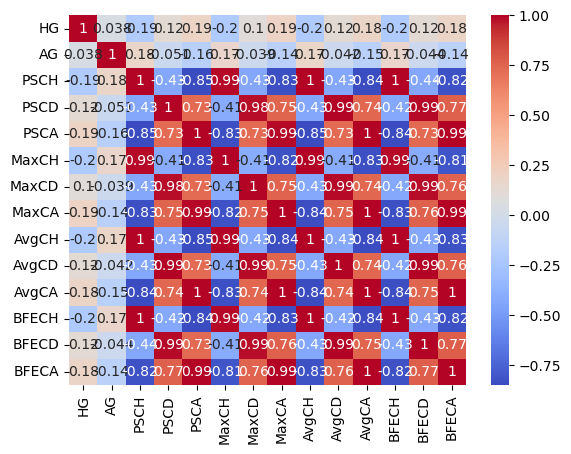

In [26]:
numeric_columns = data_dropped.select_dtypes(exclude=['object']).columns

corr_matrix = data_dropped[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()
